In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_HERE = Path.cwd()
_ROOT = _HERE.parent if _HERE.name == "EDA" else _HERE
_EDA  = _ROOT / "EDA"
for _p in (str(_ROOT), str(_EDA)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

from config import DATA_DIR, PATHS, PARAMS
from analysis_helper import (
    calculate_diversity_ratio,
    calculate_bias_metrics,
    DataAnalysisPipeline,
)
from analysis_plot import (
    plot_knee,
    plot_batch_metric_violins,
    analyze_batch_statistics,
    plot_bias_correlations,
    plot_hc_variance_and_heatmap,
    plot_hc_pca_grid,
    check_batch_classification_power,
    check_bias_power_dist,
    plot_model_auc_grid,
    check_discrete_covariate_batch_effects,
    plot_covariate_auc_heatmap,
    plot_covariate_auc_violins,
)
from viz_style import apply_style
apply_style()

## QC

In [3]:
adata = sc.read_h5ad(PATHS["merged_biases"])

In [4]:
clean_metric_labels = {
    'log1p_total_counts': 'log(Total Reads)',              
    'percent_spliced_reads': 'Spliced Reads (%)',          
    'gDNA_contamination_ratio_exon_intron': 'gDNA Contamination (Intron/Exon)', 
    'custom_content_biotype_counts-percent_rRNA': 'rRNA Fraction', 
    'DNA_degradation_bias': 'RNA Degradation (3\' Bias)',  
    'platelet_score': 'Platelet Score',            
    'gc_bias_score': 'GC Bias',                           
    'len_bias_score': 'Gene Length Bias',          
    'NG80': 'NG80',                                        
    'NP80': 'NP80',                                        
    'NP80_NG80_ratio': '(NP80/NG80)',   
    'Volume_Numeric': 'Sample Volume (mL)',               
    'Centrifuge_Total_g': 'Total Centrifugation Force (g)'       
}

adata.obs.rename(columns=clean_metric_labels, inplace=True)

In [5]:
obs = adata.obs.copy()

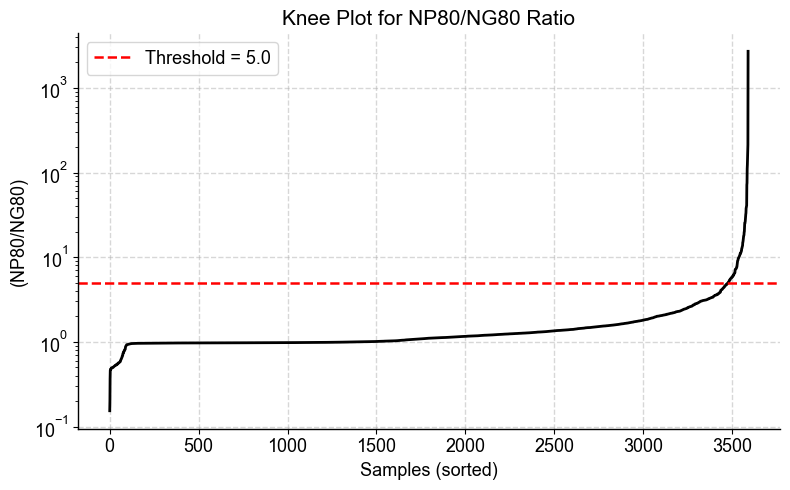

In [6]:
plot_knee(
    adata.obs["(NP80/NG80)"],
    title="Knee Plot for NP80/NG80 Ratio",
    threshold=5.0,
    save_path=None,  # was "./Analysis_Results/qc/QC_NP80NG80_Knee_Plot.png"
)

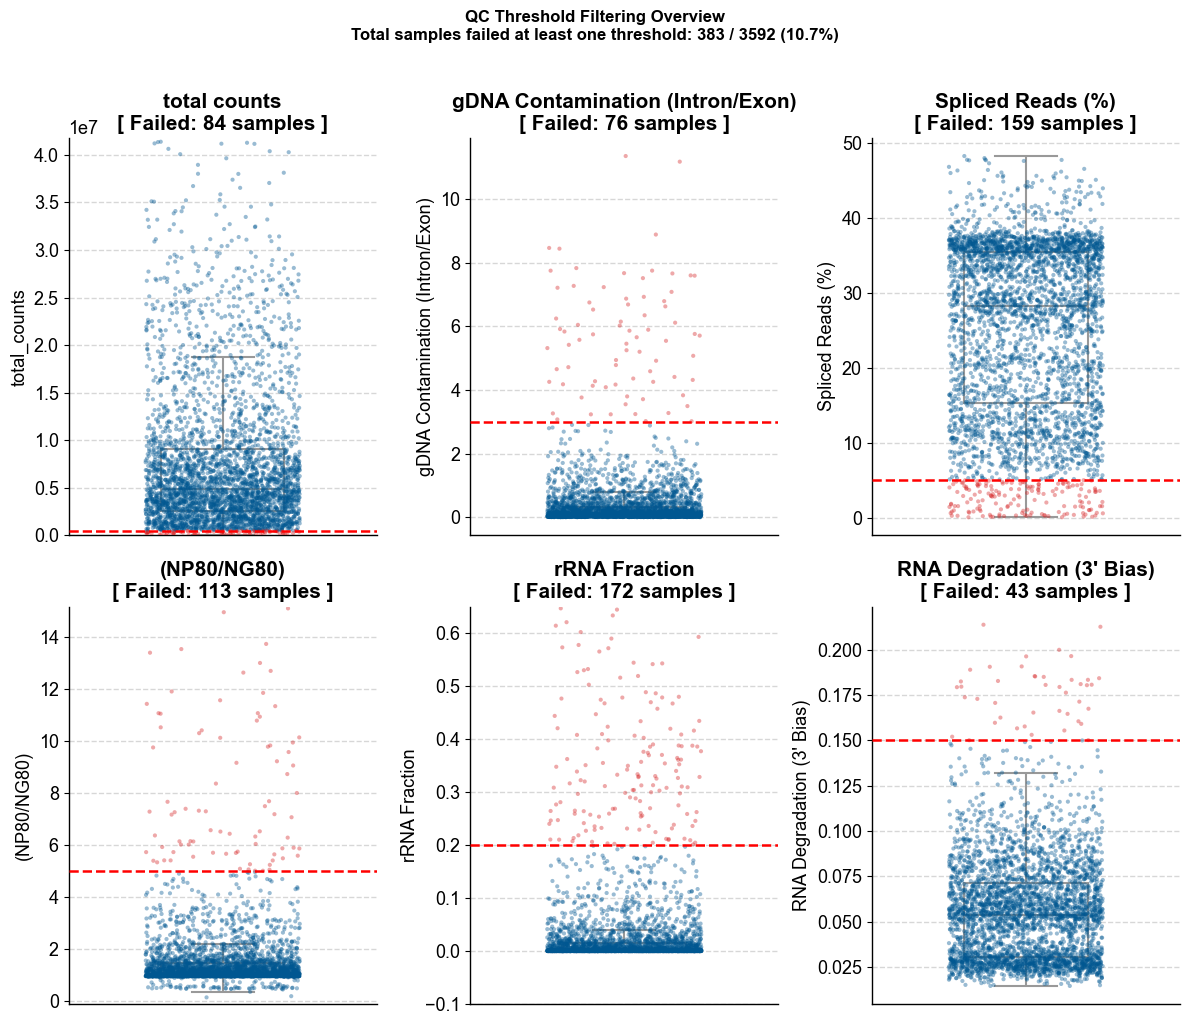

In [7]:
obs['Total_Violations'] = 0
qc_thresholds = {
    'total_counts': {'value': 500000, 'direction': 'less'},           
    'gDNA Contamination (Intron/Exon)': {'value': 3.0, 'direction': 'greater'},  
    'Spliced Reads (%)': {'value': 5.0, 'direction': 'less'},      
    '(NP80/NG80)': {'value': 5.0, 'direction': 'greater'},        
    'rRNA Fraction': {'value': 0.2, 'direction': 'greater'},
    'RNA Degradation (3\' Bias)': {'value': 0.15, 'direction': 'greater'}   
}

for metric, rules in qc_thresholds.items():
    if metric not in obs.columns: 
        continue
    
    val = rules['value']
    direction = rules['direction']
    
    if direction == 'greater':
        is_fail = obs[metric] > val
    elif direction == 'less':
        is_fail = obs[metric] < val
    else:
        raise ValueError(f"Invalid direction '{direction}' for {metric}")
        
    obs[f'{metric}_failed'] = is_fail
    obs['Total_Violations'] += is_fail.astype(int)

failed_any_count = (obs['Total_Violations'] > 0).sum()
total_samples = len(obs)
metrics = list(qc_thresholds.keys())
fig, axes = plt.subplots(2, 3, figsize=(12, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    if metric not in obs.columns:
        axes[i].axis('off')
        continue
        
    ax = axes[i]
    val = qc_thresholds[metric]['value']
    
    obs['Color_Status'] = np.where(obs[f'{metric}_failed'], 'Fail', 'Pass')
    palette = {'Pass': "#005791", 'Fail': '#d62728'}
    sns.boxplot(y=obs[metric], ax=ax, color='white', width=0.4, showfliers=False, linewidth=1.5)
    sns.stripplot(y=obs[metric], hue=obs['Color_Status'], palette=palette, 
                    data=obs, ax=ax, alpha=0.4, jitter=0.25, size=3, dodge=False)
    
    ax.axhline(val, color='red', linestyle='--', linewidth=1.8, zorder=5)
    if metric in ['total_counts', '(NP80/NG80)', 'rRNA Fraction']:
        upper_limit = obs[metric].quantile(0.99)
        ax.set_ylim(bottom=-0.1, top=upper_limit * 1.2)
    else:
        ax.set_ylabel(metric)
        
    ax.set_xticks([])
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    
    # Annotate individual fail count in subplot title
    fail_count = obs[f'{metric}_failed'].sum()
    ax.set_title(f"{metric.replace('_', ' ')}\n[ Failed: {fail_count} samples ]", 
                    fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# 4. Global Title with Total Unique Failures
fig.suptitle(
    f"QC Threshold Filtering Overview\n"
    f"Total samples failed at least one threshold: {failed_any_count} / {total_samples} "
    f"({(failed_any_count/total_samples)*100:.1f}%)", 
    fontweight='bold', y=1.02
)

plt.tight_layout()
# plt.savefig("./Analysis_Results/qc/QC_boxplot.png")

,total_counts_failed,gDNA Contamination (Intron/Exon)_failed,Spliced Reads (%)_failed,(NP80/NG80)_failed,rRNA Fraction_failed,RNA Degradation (3' Bias)_failed,Total_Dropped
Batch_ID,,,,,,,
Block et al._Batch_1,10.344828,75.862069,82.758621,3.448276,0.000000,3.448276,82.758621
Chalasani et al._Batch_1,0.301205,0.000000,0.000000,0.000000,0.000000,0.000000,0.301205
Chang et al._Batch_1,0.000000,0.000000,14.285714,0.000000,0.000000,0.000000,14.285714
Chang et al._Batch_2,2.439024,0.000000,9.756098,0.000000,0.000000,0.000000,9.756098
Chang et al._Batch_3,0.000000,0.000000,0.000000,16.666667,2.777778,0.000000,16.666667
Chang et al._Batch_4,0.000000,2.941176,2.941176,0.000000,0.000000,0.000000,2.941176
Chang et al._Batch_5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Chang et al._Batch_6,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000,50.000000
Chang et al._Batch_7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


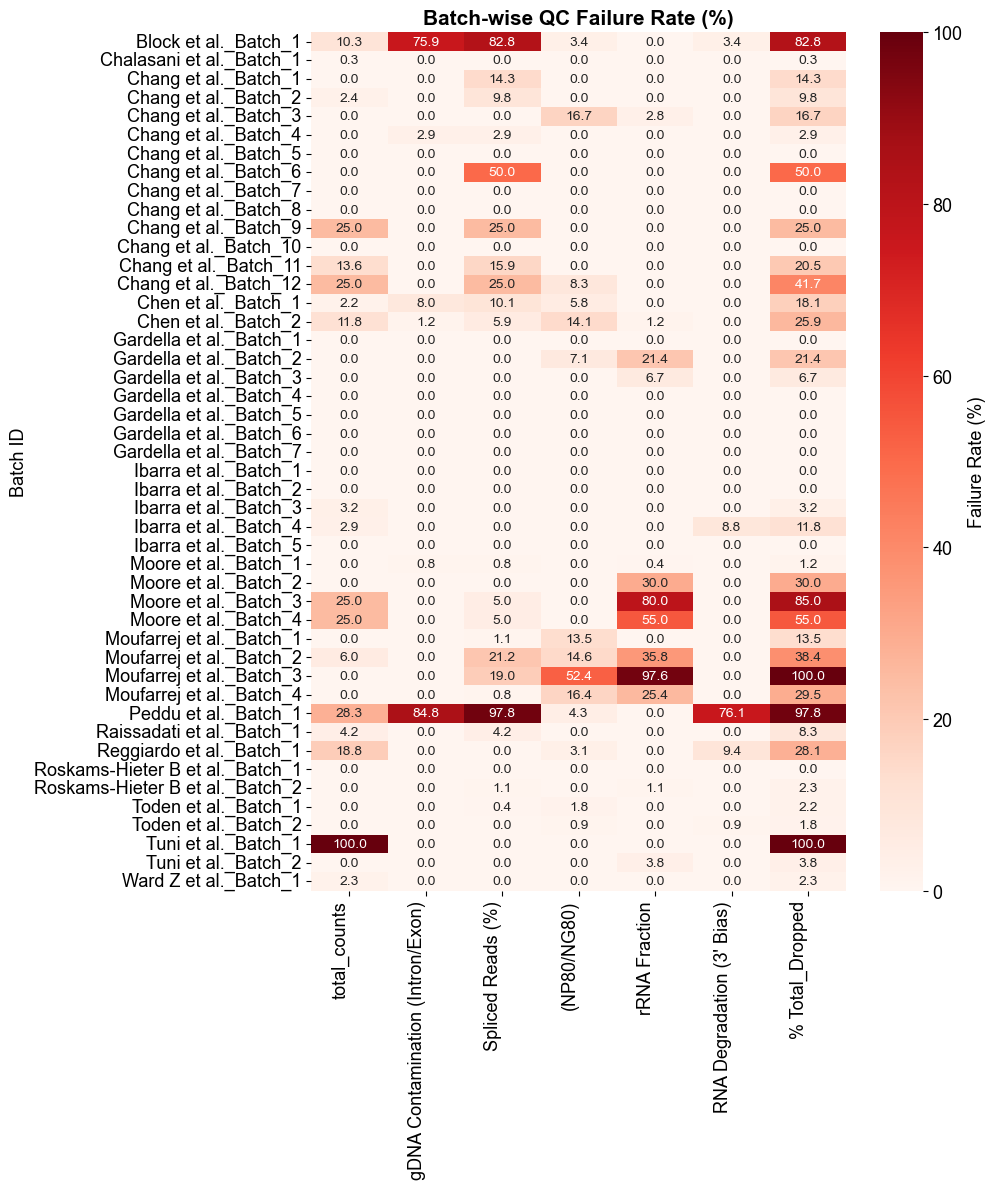

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fail_cols = obs.columns[obs.columns.str.endswith('_failed')]
obs['Total_Dropped'] = obs[fail_cols].any(axis=1)
summary_cols = list(fail_cols) + ['Total_Dropped']
batch_summary = obs.groupby('Batch_ID')[summary_cols].mean() * 100
clean_labels = [c.replace('_failed', '') for c in fail_cols] + ['% Total_Dropped']
fig, ax = plt.subplots(figsize=(10, 12))

sns.heatmap(
    batch_summary, 
    annot=True, fmt=".1f", cmap="Reds", 
    cbar_kws={'label': 'Failure Rate (%)'}, ax=ax
)

ax.set_title("Batch-wise QC Failure Rate (%)", fontweight='bold')
ax.set_ylabel("Batch ID")
ax.set_xticklabels(clean_labels, rotation=90, ha='right')

plt.tight_layout()
# plt.savefig("./Analysis_Results/qc/QC_Dropped_Ratio_Heatmap.png")

batch_summary

In [9]:
obs["QC_Passed"] = ~obs["Total_Dropped"]
obs.drop(columns=["Total_Dropped", "Color_Status", "total_counts_failed"], inplace=True)
adata.obs = obs.copy()
# adata.write_h5ad(PATHS["merged_qc"])